In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat, loadmat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
import save_data_helpers

In [14]:
idx, resp_trimmed, data_bins, spoke_bins, index_bins = save_data_helpers.load_gate_outputs_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl')
p_gates_all= loadmat('phil_gates.mat')

Loaded /home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl
  idx shape: (113116,)
  signal_trimmed shape: (113116,)
  data_bins: 5 elements
  spoke_bins: 5 elements
  index_bins: 5 elements


In [67]:
print(spoke_bins[0].shape)

(22623, 512, 3)


In [11]:
num_gates = 5
p_gates = []
for i in range(1, num_gates+1):
    gate_name = f'gate{i}'
    gate_data = p_gates_all[gate_name].ravel()
    print(f'gate_data.shape = {gate_data.shape}')
    p_gates.append(gate_data)

print(f'len(p_gates) = {len(p_gates)}')

gate_data.shape = (365,)
gate_data.shape = (365,)
gate_data.shape = (365,)
gate_data.shape = (365,)
gate_data.shape = (365,)
len(p_gates) = 5


In [62]:
def ga_2d_readout_from_spokes(kmax, spoke_list, num_points):
    """2D golden angle kspace trajectory"""
    tmp = np.linspace(-kmax, kmax, num_points)
    k = np.zeros((len(spoke_list), num_points, 2))
    
    ga = np.pi / ((1 + np.sqrt(5)) / 2)  # Golden angle
    
    for i in range(len(spoke_list)):
        # print(f'spoke[{i}] = {spoke_list[i]}')
        phi = (spoke_list[i] * ga) % (2 * np.pi)
        k[i, :, 0] = tmp * np.cos(phi)
        k[i, :, 1] = tmp * np.sin(phi)
    
    return k


def get_ga_coords_3d_from_spokes(img_shape, spoke_list, num_points):
    """Generate 3D stack-of-stars golden angle coordinates"""
    # Generate 2D golden angle spokes
    coords_2d = ga_2d_readout_from_spokes(img_shape[1]//2, spoke_list, num_points)
    
    # Stack across partitions with kz encoding
    shape_3d = [img_shape[0]] + list(coords_2d.shape)
    shape_3d[3] += 1  # Add dimension for kz
    
    coords_3d = np.zeros(shape_3d, dtype=coords_2d.dtype)
    slice_coords = np.linspace(-img_shape[0]/2., img_shape[0]/2., img_shape[0])
    
    for i in range(img_shape[0]):
        coords_3d[i, :, :, 1:] = coords_2d  # kx, ky
        coords_3d[i, :, :, 0] = slice_coords[i]  # kz
    
    return coords_3d

In [63]:
from gating_visuals import view_angular_converage
img_shape = (58, 512, 512)
coordinate_bins = []

for i in range(5):
    spokes_for_gate = p_gates[i]
    coords = get_ga_coords_3d_from_spokes(img_shape, spoke_list=spokes_for_gate, num_points=512)
    print(f'Gate {i}: coords.shape = {coords.shape}')
    coordinate_bins.append(coords)

print(f'len(coordinate_bins) = {len(coordinate_bins)}')

Gate 0: coords.shape = (58, 365, 512, 3)
Gate 1: coords.shape = (58, 365, 512, 3)
Gate 2: coords.shape = (58, 365, 512, 3)
Gate 3: coords.shape = (58, 365, 512, 3)
Gate 4: coords.shape = (58, 365, 512, 3)
len(coordinate_bins) = 5


Gate 1: coords.shape = (58, 365, 512, 3)
Gate 2: coords.shape = (58, 365, 512, 3)
Gate 3: coords.shape = (58, 365, 512, 3)
Gate 4: coords.shape = (58, 365, 512, 3)
Gate 5: coords.shape = (58, 365, 512, 3)


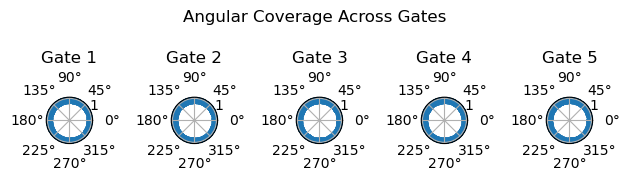

In [ ]:
## Quick sanity check
for gate_idx in range(len(coordinate_bins)):
    num_samples = 512

    coords = coordinate_bins[gate_idx]  # shape: (num_spokes, num_slices, num_samples, ndims)
    print(f'Gate {gate_idx + 1}: coords.shape = {coords.shape}')
    
    # Extract center of k-space or first readout point from each spokegati
    # Use middle slice for visualization
    middle_slice = 20
    kx = coords[middle_slice, :, num_samples//2, 2]  
    ky = coords[middle_slice, :, num_samples//2, 1]
    
    # Calculate angles
    angles = np.arctan2(ky, kx)  # radians, range [-π, π]

    # Polar plot
    ax = plt.subplot(1, 5, gate_idx+1, projection='polar')
    ax.scatter(angles, np.ones_like(angles))  # radius=1 for all
    ax.set_title(f'Gate {gate_idx + 1}')
    plt.tight_layout()
    plt.suptitle(f'Angular Coverage Across Gates', y =0.70)
    
plt.show()

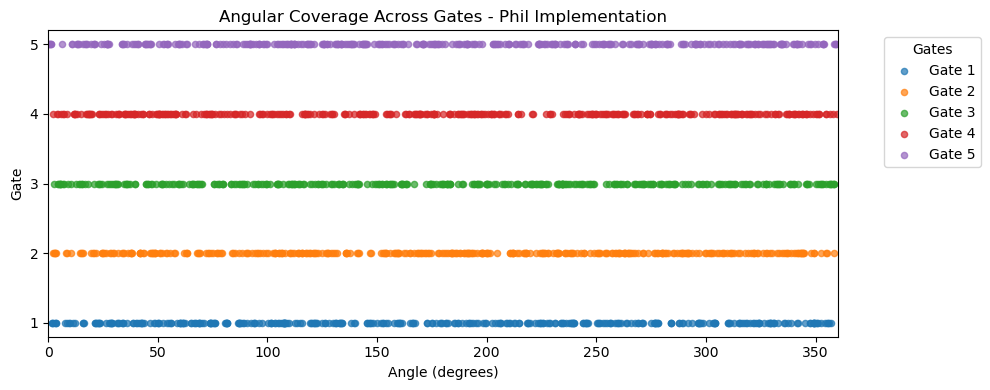

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Example: assuming coordinate_bins is a list of arrays, one per gate
# coordinate_bins[gate_idx].shape = (num_slices, num_spokes, num_samples, ndims)

num_gates = len(coordinate_bins)
middle_slice = 20
num_samples = 512

plt.figure(figsize=(10, 4))

for gate_idx in range(num_gates):
    coords = coordinate_bins[gate_idx]
    
    # Extract center of k-space (or first readout point) for middle slice
    kx = coords[middle_slice, :, num_samples//2, 2]  # x
    ky = coords[middle_slice, :, num_samples//2, 1]  # y
    
    # Compute angles in degrees [0, 360)
    angles_deg = np.degrees(np.arctan2(ky, kx)) % 360
    
    # Plot each angle as a dot at the corresponding gate index
    plt.scatter(angles_deg, np.full_like(angles_deg, gate_idx + 1), label=f'Gate {gate_idx + 1}', alpha=0.7, s=20)

plt.xlabel("Angle (degrees)")
plt.ylabel("Gate")
plt.yticks(range(1, num_gates + 1))
plt.xlim(0, 360)
plt.title("Angular Coverage Across Gates - Phil Implementation")
plt.legend(title="Gates", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


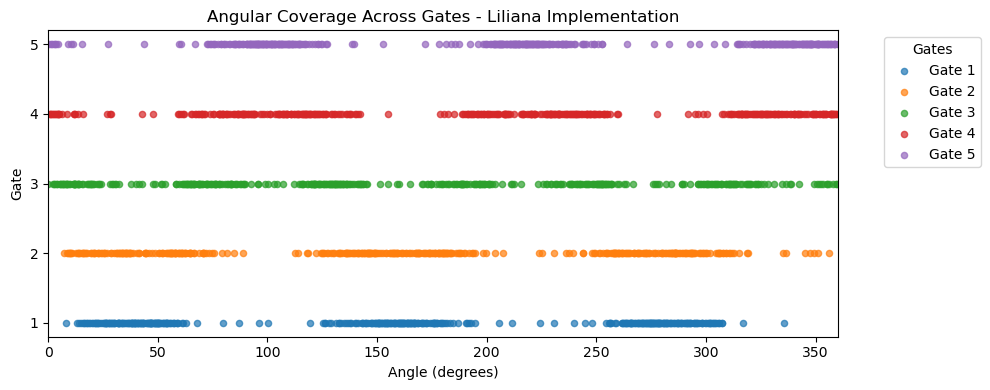

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Example: assuming coordinate_bins is a list of arrays, one per gate
# coordinate_bins[gate_idx].shape = (num_slices, num_spokes, num_samples, ndims)

num_gates = len(spoke_bins)
middle_slice = 20
num_samples = 512

plt.figure(figsize=(10, 4))

for gate_idx in range(num_gates):
    coords = spoke_bins[gate_idx]
    
    # Extract center of k-space (or first readout point) for middle slice
    kx = coords[::57, num_samples//2, 2]  # x
    ky = coords[::57, num_samples//2, 1]  # y
    
    # Compute angles in degrees [0, 360)
    angles_deg = np.degrees(np.arctan2(ky, kx)) % 360
    
    # Plot each angle as a dot at the corresponding gate index
    plt.scatter(angles_deg, np.full_like(angles_deg, gate_idx + 1), label=f'Gate {gate_idx + 1}', alpha=0.7, s=20)

plt.xlabel("Angle (degrees)")
plt.ylabel("Gate")
plt.yticks(range(1, num_gates + 1))
plt.xlim(0, 360)
plt.title("Angular Coverage Across Gates - Liliana Implementation")
plt.legend(title="Gates", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
